In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os 
import sys

from astropy.visualization import astropy_mpl_style

from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.units import Quantity

from pyvo.dal import tap

import pandas as pd

ESO_TAP_OBS = "http://archive.eso.org/tap_obs"

tapobs = tap.TAPService(ESO_TAP_OBS)

import requests
import cgi
import json

import getpass

In [2]:
# Spectrum FITS file
hdul = fits.open('ADP.2019-03-12T05_26_43.817.fits')
header = hdul[0].header
data = hdul[1].data
data.columns

ColDefs(
    name = 'WAVE'; format = '147467D'; unit = 'Angstrom'
    name = 'FLUX'; format = '147467D'
    name = 'ERR'; format = '147467D'
    name = 'CONTINUUM'; format = '147467D'
    name = 'STATUS'; format = '147467J'
    name = 'NPBCLIP'; format = '147467I'
    name = 'NPACLIP'; format = '147467I'
    name = 'CHBCLIP'; format = '147467D'
    name = 'CHACLIP'; format = '147467D'
)

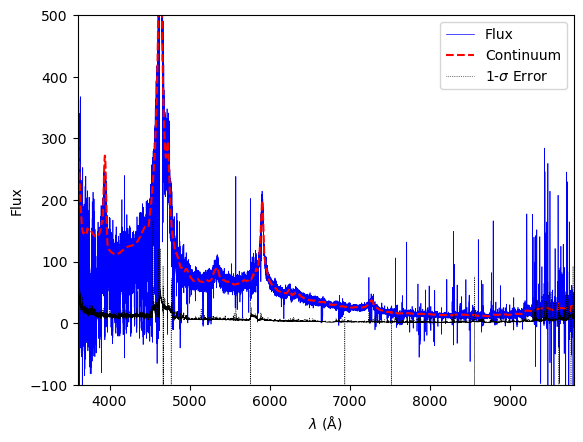

In [3]:
# Spectra Plotting
wave = data['WAVE'][0] 
flux = data['FLUX'][0] # normailized by the continuum
err = data['ERR'][0] # normailized by the continuum - determined from the quasar flux, sky flux and CCD noise characteristics
mu = data['CONTINUUM'][0]
plt.figure(1)
plt.plot(wave, flux*mu,'b',label="Flux",linewidth=0.5)
plt.plot(wave, mu, 'r--',  label="Continuum")
plt.plot(wave, err*mu, 'k:', label="1-$\sigma$ Error",linewidth=0.5)
plt.xlabel('$\lambda$ (Å)')
plt.ylabel('Flux')
plt.xlim(3600, 9800)
plt.ylim(-100,500)
plt.legend()


In [4]:
target_name = 'J000149-015939'

query = """SELECT *
FROM ivoa.ObsCore
WHERE target_name = '%s'""" % (target_name)

# ivorn = 'ivo://eso.org/ID?' + dp_id
# query = """SELECT *
# FROM ivoa.ObsCore
# WHERE obs_publisher_did = '%s'""" % (ivorn)

print(query)

SELECT *
FROM ivoa.ObsCore
WHERE target_name = 'J000149-015939'


In [5]:
res = tapobs.search(query=query)
res_table = res.to_table()
# for colname in res.to_table().colnames:
#     print(colname)

dp_id = res_table["dp_id"]

file_url = 'https://dataportal.eso.org/dataportal_new/file/' + dp_id[0]
print(file_url)

https://dataportal.eso.org/dataportal_new/file/ADP.2019-03-12T05:26:43.817


In [10]:
tab = Table.read("apjabbb34t1_mrt.txt", format="ascii.cds")

uves_spectra_bool = (tab["Fac"] == "UVES") | (tab["Fac"] == "HIRES+UVES")
uves_spectra = tab["QSO"][uves_spectra_bool]
print(uves_spectra)


      QSO      
---------------
 J000149-015939
 J000344-232355
 J000448-415728
 J001130+005550
 J001210-012207
 J001306+000431
 J001602-001225
 J002133+004301
 J002151-012833
 J004428-243417
            ...
 J230001-341319
 J231646-404120
 J232059-295521
 J232121-294350
 J232820+002238
 J234625+124743
J234819+005721A
 J234825+002040
 J235034-432559
 J235057-005209
Length = 137 rows


In [15]:
valid_targets = []
for obj in uves_spectra: 
    # Querey each spectra by their target name
    query = """SELECT *
    FROM ivoa.ObsCore
    WHERE target_name = '%s'""" % (obj)
    res = tapobs.search(query=query)
    res_table = res.to_table()

    dp_id = res_table["dp_id"] # extract their unique ESO identifier
    if len(dp_id) > 0:  # ensures that a data file exists for this target
        valid_targets.append(dp_id[0])


In [18]:
def getDispositionFilename( response ):
    """Get the filename from the Content-Disposition in the response's http header"""
    contentdisposition = response.headers.get('Content-Disposition')
    if contentdisposition == None:
        return None
    value, params = cgi.parse_header(contentdisposition)
    filename = params["filename"]
    return filename

def writeFile( response ):
    """Write on disk the retrieved file"""
    if response.status_code == 200:
        # The ESO filename can be found in the response header
        filename = getDispositionFilename( response )
        # Let's write on disk the downloaded FITS spectrum using the ESO filename:
        with open(filename, 'wb') as f:
            f.write(response.content)
        return filename 

In [21]:
for dp_id in valid_targets:
    file_url = 'https://dataportal.eso.org/dataportal_new/file/' + dp_id
    response = requests.get(file_url)
    filename = writeFile( response )
    if filename:
        print("Saved file: %s" % (filename))
    else:
        print("Could not get file (status: %d)" % (response.status_code))

Saved file: ADP.2019-03-12T05:26:43.817.fits
Saved file: ADP.2019-03-12T05:26:43.823.fits


KeyboardInterrupt: 

In [22]:
valid_targets

['ADP.2019-03-12T05:26:43.817',
 'ADP.2019-03-12T05:26:43.823',
 'ADP.2019-03-12T05:26:43.826',
 'ADP.2019-03-12T05:26:43.847',
 'ADP.2019-03-12T05:26:43.841',
 'ADP.2019-03-12T05:26:43.844',
 'ADP.2019-03-12T05:26:43.850',
 'ADP.2019-03-12T05:26:43.889',
 'ADP.2019-03-12T05:26:43.898',
 'ADP.2019-03-12T05:26:43.907',
 'ADP.2019-03-12T05:26:43.910',
 'ADP.2019-03-12T05:26:43.916',
 'ADP.2019-03-12T05:26:43.913',
 'ADP.2019-03-12T05:26:43.922',
 'ADP.2019-03-12T05:26:43.928',
 'ADP.2019-03-12T05:26:43.925',
 'ADP.2019-03-12T05:26:43.934',
 'ADP.2019-03-12T05:26:43.931',
 'ADP.2019-03-12T05:26:43.943',
 'ADP.2019-03-12T05:26:43.946',
 'ADP.2019-03-12T05:26:43.961',
 'ADP.2019-03-12T05:26:43.970',
 'ADP.2019-03-12T05:26:43.997',
 'ADP.2019-03-12T05:26:44.018',
 'ADP.2019-03-12T05:26:44.012',
 'ADP.2019-03-12T05:26:44.030',
 'ADP.2019-03-12T05:26:44.042',
 'ADP.2019-03-12T05:26:44.051',
 'ADP.2019-03-12T05:26:44.072',
 'ADP.2019-03-12T05:26:44.078',
 'ADP.2019-03-12T05:26:44.075',
 'ADP.20